<a href="https://colab.research.google.com/github/benedettalava/stock-market-forecasting-rnn-vecm/blob/main/oil_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction and Economic Motivation of Feature Selection**

The objective of this study is to forecast the short-term dynamics of the Italian equity index (FTSE MIB). Rather than relying solely on univariate historical price series, the modeling framework incorporates two key exogenous financial variables as predictors: the S&P 500 index and Crude Oil prices. The selection of these variables is grounded in solid financial theory and structural market dependencies:

Global Market Leadership and Spillover Effects (S&P 500):
The U.S. stock market plays a dominant role in driving international financial sentiment. European equity markets—and the FTSE MIB in particular—exhibit a strong systematic dependency on U.S. indices, frequently following the directional trends set by the S&P 500. Due to market opening hours and global information propagation, price movements and sentiment shifts in the U.S. serve as a major leading signal for European trading sessions. While the S&P 500 represents a highly diversified basket of global large-cap equities, it captures broader macroeconomic cycles and global risk appetite.

Sectoral Composition and Energy Sensitivity (Crude Oil):
Unlike broadly diversified global indices, the FTSE MIB has a distinctive sector allocation characterized by a heavy weight in energy, industrial, and utility giants (such as Eni, Saipem, and Tenaris). Consequently, Crude Oil prices act as a direct fundamental proxy for the cash flow expectations and performance of a significant portion of the Italian index. Fluctuations in energy markets directly affect the valuation of these major constituent stocks, making Crude Oil an essential commodity factor for capturing domestic market variations.

By combining the S&P 500 (representing global market sentiment and macroeconomic trends) and Crude Oil (representing targeted sectoral dynamics and energy-driven fundamentals), the dataset provides a rich, complementary set of predictors to model and forecast the daily dynamics of the FTSE MIB.

### Introduction and Economic Motivation of Feature Selection (Corrected)

The objective of this study is to forecast the short-term dynamics of the Italian equity index (FTSE MIB). Rather than relying solely on univariate historical price series, the modeling framework incorporates two key exogenous financial variables as predictors: the S&P 500 index and Crude Oil prices. The selection of these variables is grounded in solid financial theory and structural market dependencies:

**Global Market Leadership and Spillover Effects (S&P 500):**
The U.S. stock market plays a dominant role in driving international financial sentiment. European equity markets—and the FTSE MIB in particular—exhibit a strong systematic dependency on U.S. indices, frequently following the directional trends set by the S&P 500. Due to market opening hours and global information propagation, price movements and sentiment shifts in the U.S. serve as a major leading signal for European trading sessions. While the S&P 500 represents a highly diversified basket of global large-cap equities, it captures broader macroeconomic cycles and global risk appetite.

**Sectoral Composition and Energy Sensitivity (Crude Oil):**
Unlike broadly diversified global indices, the FTSE MIB has a distinctive sector allocation characterized by a heavy weighting in energy, industrial, and utility giants (such as Eni, Saipem, and Tenaris). Consequently, Crude Oil prices act as a direct fundamental proxy for the cash flow expectations and performance of a significant portion of the Italian index. Fluctuations in energy markets directly affect the valuation of these major constituent stocks, making Crude Oil an essential commodity factor for capturing domestic market variations.

By combining the S&P 500 (representing global market sentiment and macroeconomic trends) and Crude Oil (representing targeted sectoral dynamics and energy-driven fundamentals), the dataset provides a rich, complementary set of predictors to model and forecast the daily dynamics of the FTSE MIB.

Fist step: upgrade or install libraries

### First step: upgrade or install libraries (Corrected)

First step: upgrade or install libraries

In [ ]:
# Run this cell and then restart the runtime to apply the update.

!pip install --upgrade statsmodels
!pip install arch

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from arch.unitroot import PhillipsPerron
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

#RNN
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
TICKERS = {
    "Petrolio_WTI_USD": "CL=F",
    "FTSE_MIB": "FTSEMIB.MI",
    "SP500": "^GSPC",
}


In [ ]:

data = yf.download(
    list(TICKERS.values()),
    start="2015-01-01",
    end = "2026-01-01",
    auto_adjust=True,
    progress=False
)


In [ ]:
data.head()

Price           Close                               High             \
Ticker           CL=F FTSEMIB.MI        ^GSPC       CL=F FTSEMIB.MI   
Date                                                                  
2015-01-02  52.689999    19130.0  2058.199951  55.110001    19247.0   
2015-01-05  50.040001    18188.0  2020.579956  52.730000    19190.0   
2015-01-06  47.930000    18143.0  2002.609985  50.369999    18524.0   
2015-01-07  48.650002    18123.0  2025.900024  49.310001    18478.0   
2015-01-08  48.790001    18792.0  2062.139893  49.650002    18858.0   

Price                          Low                               Open  \
Ticker            ^GSPC       CL=F FTSEMIB.MI        ^GSPC       CL=F   
Date                                                                    
2015-01-02  2072.360107  52.029999    18920.0  2046.040039  53.759998   
2015-01-05  2054.439941  49.680000    18188.0  2017.339966  52.610001   
2015-01-06  2030.250000  47.549999    18041.0  1992.439941  50.000000   
2015-01-07  2029.609985  46.830002    17992.0  2005.550049  48.000000   
2015-01-08  2064.080078  47.730000    18248.0  2030.609985  48.779999   

Price                                 Volume                           
Ticker     FTSEMIB.MI        ^GSPC      CL=F FTSEMIB.MI         ^GSPC  
Date                                                                   
2015-01-02    19157.0  2058.899902  268708.0        0.0  2.708700e+09  
2015-01-05    18961.0  2054.439941  375782.0        0.0  3.799120e+09  
2015-01-06    18298.0  2022.150024  451642.0        0.0  4.460110e+09  
2015-01-07    18226.0  2005.550049  460083.0        0.0  3.805480e+09  
2015-01-08    18393.0  2030.609985  362081.0        0.0  3.934010e+09

In [ ]:
# we start taking the price at the closure

prices = data["Close",]
prices.head()

Ticker,CL=F,FTSEMIB.MI,^GSPC
Date,,,
2015-01-02,52.689999,19130.0,2058.199951
2015-01-05,50.040001,18188.0,2020.579956
2015-01-06,47.930000,18143.0,2002.609985
2015-01-07,48.650002,18123.0,2025.900024
2015-01-08,48.790001,18792.0,2062.139893


In [ ]:
prices.tail()

Ticker,CL=F,FTSEMIB.MI,^GSPC
Date,,,
2025-12-24,58.349998,NaN,6932.049805
2025-12-26,56.740002,NaN,6929.939941
2025-12-29,58.080002,44436.0,6905.740234
2025-12-30,57.950001,44945.0,6896.240234
2025-12-31,57.419998,NaN,6845.500000


In [ ]:
# we rename variables

prices = prices.rename(columns = {"CL=F" : "Oil", "FTSEMIB.MI" : "FTSE_MIB", "^GSPC" : "SP500" })
prices.head()

Ticker,Oil,FTSE_MIB,SP500
Date,,,
2015-01-02,52.689999,19130.0,2058.199951
2015-01-05,50.040001,18188.0,2020.579956
2015-01-06,47.930000,18143.0,2002.609985
2015-01-07,48.650002,18123.0,2025.900024
2015-01-08,48.790001,18792.0,2062.139893


To create plots using pandas dataframes, we need to have column data

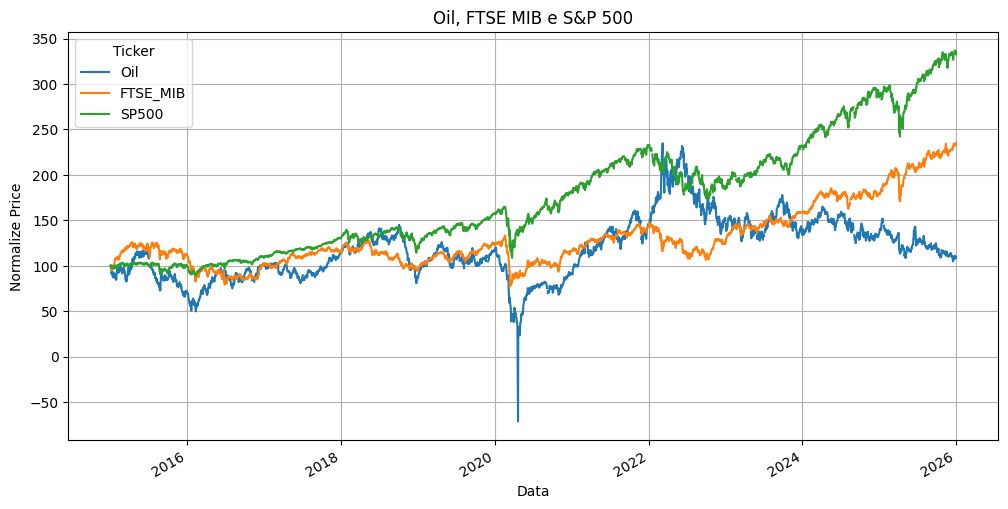

In [ ]:
# plotting the series, normalizing using the first row

prices_norm = prices / prices.iloc[0] * 100

prices_norm.plot(figsize=(12, 6))
plt.title("Oil, FTSE MIB e S&P 500")
plt.xlabel("Data")
plt.ylabel("Normalize Price")
plt.grid(True)
plt.show()

It seems that FTSE_MIB has captured the shock of oil before SP500 along the time.

### Observation on FTSE_MIB and Oil (Corrected)

It seems that FTSE_MIB has reacted to the oil shock before SP500 over time.

It seems that SP500 and FTSE_MIB are connected in some way

### Observation on SP500 and FTSE_MIB Connection (Corrected)

It seems that SP500 and FTSE_MIB are connected in some way.

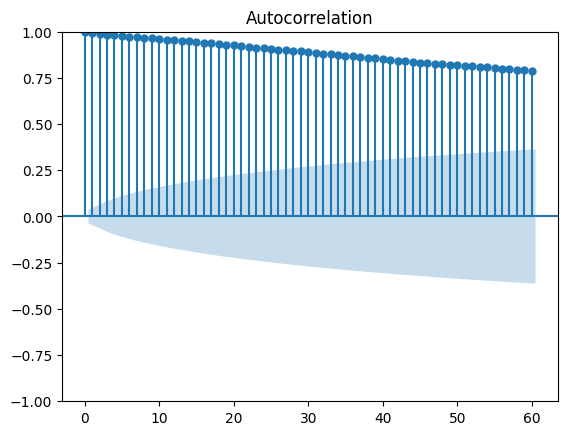

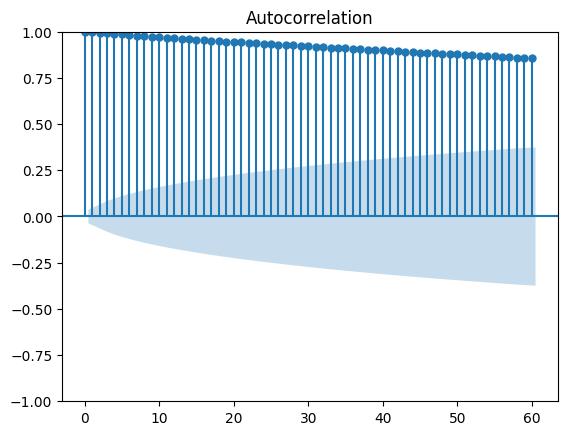

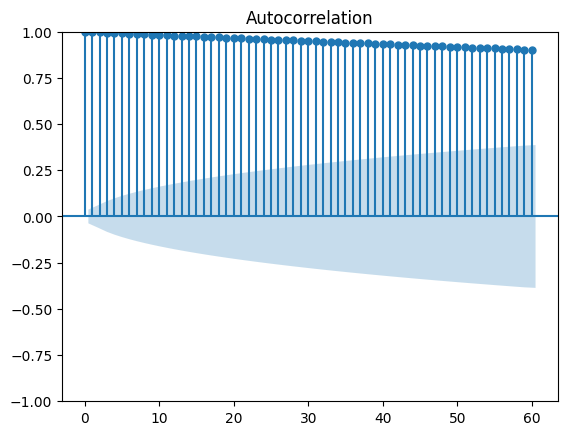

In [ ]:
# We study the stationarity

plot_acf(prices["Oil"].dropna(), lags=60)
plt.show()

plot_acf(prices["FTSE_MIB"].dropna(), lags=60)
plt.show()

plot_acf(prices["SP500"].dropna(), lags=60)
plt.show()

All series aren't stationary. We check the stationarity of the logaritm of returns

### Stationarity Check for Log-Returns (Corrected)

All series are not stationary. We will now check the stationarity of the log-returns.

In [ ]:
log_returns = np.log(prices).diff()
log_returns.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Ticker,Oil,FTSE_MIB,SP500
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.051603,-0.050496,-0.018447
2015-01-06,-0.043081,-0.002477,-0.008933
2015-01-07,0.014910,-0.001103,0.011563
2015-01-08,0.002874,0.036249,0.017730


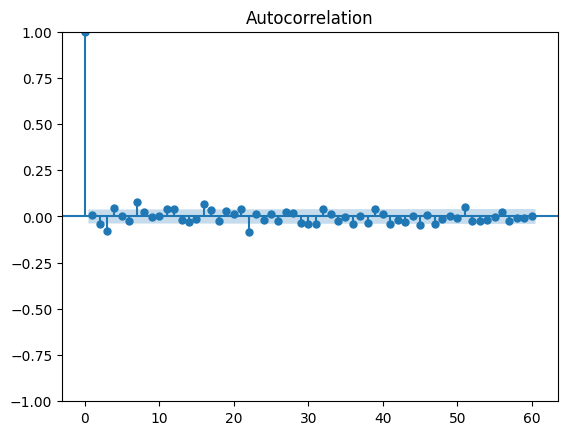

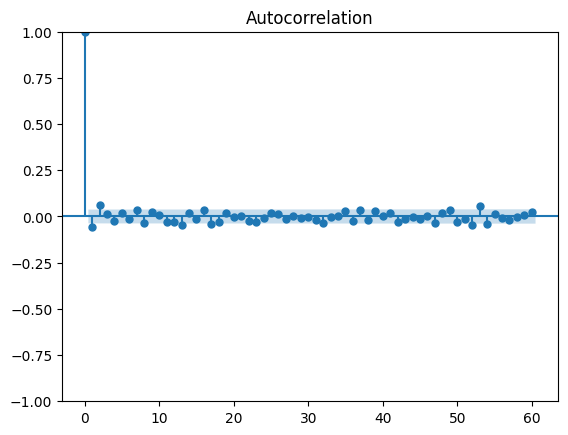

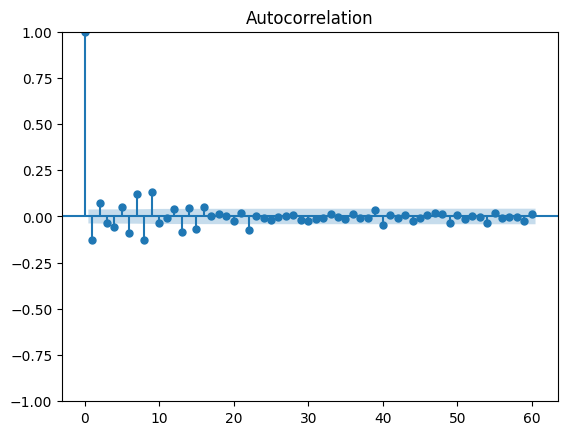

In [ ]:
plot_acf(log_returns["Oil"].dropna(), lags=60)
plt.show()

plot_acf(log_returns["FTSE_MIB"].dropna(), lags=60)
plt.show()

plot_acf(log_returns["SP500"].dropna(), lags=60)
plt.show()

In [ ]:

returns_clean = log_returns.dropna()[["Oil", "FTSE_MIB", "SP500"]]

def test_return_stationarity(df):
    results = []

    for col in df.columns:
        series = df[col]

        # --- TEST ADF (Augmented Dickey-Fuller) ---
        adf_res = adfuller(series, regression='c', autolag='AIC')
        adf_stat, adf_p = adf_res[0], adf_res[1]

        # --- TEST PP (Phillips-Perron) ---
        pp_res = PhillipsPerron(series, trend='c')
        pp_stat, pp_p = pp_res.stat, pp_res.pvalue

        # --- TEST KPSS ---
        kpss_res = kpss(series, regression='c', nlags='auto')
        kpss_stat, kpss_p = kpss_res[0], kpss_res[1]

        is_stationary = (adf_p < 0.05) and (pp_p < 0.05) and (kpss_p > 0.05)

        results.append({
            "Variable": col,
            "ADF p-val": round(adf_p, 5),
            "PP p-val": round(pp_p, 5),
            "KPSS p-val": round(kpss_p, 5),
            "Conclusione": "Stationary" if is_stationary else "Strange"
        })

    return pd.DataFrame(results)


In [ ]:

# Esecuzione dei test
stationarity_summary = test_return_stationarity(returns_clean)
print("==========================================================")
print(" Stationary test")
print("==========================================================")
print(stationarity_summary.to_string(index=False))

/tmp/ipykernel_2148/489973622.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_2148/489973622.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='c', nlags='auto')


 Stationary test
Variable  ADF p-val  PP p-val  KPSS p-val Conclusione
     Oil        0.0       0.0         0.1  Stationary
FTSE_MIB        0.0       0.0         0.1  Stationary
   SP500        0.0       0.0         0.1  Stationary


/tmp/ipykernel_2148/489973622.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='c', nlags='auto')


As we expected, the returns are stationary almost for all the lags

### Conclusion on Returns Stationarity (Corrected)

As expected, the returns are stationary for almost all lags.

Now we can start the modelling part. As we saw previuosly, SP500 e FITB_MI seems to be cointegrated so the first step is using the logaritm of prices and then evaluate the presence of cointegration using tests made for this.

For now, we will focus only on SP500 e FITB_MI series.

### Modeling Part Introduction (Corrected)

Now we can start the modeling part. As we previously observed, SP500 and FTSE_MIB seem to be cointegrated, so the first step is to use the logarithm of prices and then evaluate the presence of cointegration using appropriate tests.

For now, we will focus only on the SP500 and FTSE_MIB series.

Log prices are used because they reduce scale differences between assets, stabilize the variance of financial time series, and convert multiplicative price changes into additive log-returns, making the data more suitable and easier to model with statistical and econometric methods.

In [ ]:

log_prices = np.log(prices)
log_prices.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Ticker,Oil,FTSE_MIB,SP500
Date,,,
2015-01-02,3.964426,9.859013,7.629587
2015-01-05,3.912823,9.808517,7.611140
2015-01-06,3.869742,9.806040,7.602207
2015-01-07,3.884652,9.804937,7.613769
2015-01-08,3.887525,9.841187,7.631500


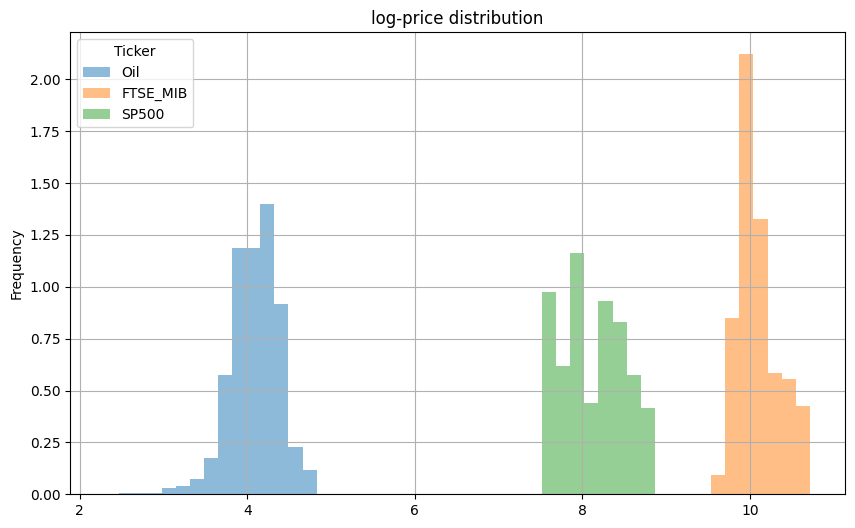

In [ ]:
log_prices.plot.hist(bins=50, alpha=0.5, figsize=(10,6), density=True)
plt.title("log-price distribution")
plt.grid(True)
plt.show()

We start with ADF. Remember you need to drop missed values genrated by negative logaritms.

**Theory:** The null hypothesis of the Augmented Dickey-Fuller is that there is a unit root, with the alternative that there is no unit root. If the pvalue is above a critical size, then we cannot reject that there is a unit root.

### Augmented Dickey-Fuller (ADF) Test (Corrected)

We start with the ADF test. Remember to drop missing values generated by negative logarithms.

**Theory:** The null hypothesis of the Augmented Dickey-Fuller test is that there is a unit root, with the alternative hypothesis that there is no unit root. If the p-value is above a critical value, then we cannot reject the null hypothesis of a unit root.

In all possible specifications, the test evaluates the presence of a unit root ($H_0$: Non-Stationary) against the alternative ($H_1$: Stationary) within a chosen deterministic framework.

1. Constant Only (regression='c')$H_0$: The series has a unit root and behaves as a Random Walk with Drift.$H_1$: The series is Stationary around a constant mean (mean-reverting).

2. Constant and Linear Trend (regression='ct')$H_0$: The series has a unit root with a linear drift.$H_1$: The series is Trend-Stationary (stationary after removing a linear deterministic trend).

3. Constant, Linear, and Quadratic Trend (regression='ctt')$H_0$: The series has a unit root with an accelerating/quadratic drift.$H_1$: The series is Stationary around a quadratic trend (stationary after removing a parabolic trend).

4. No Constant, No Trend (regression='n')$H_0$: The series has a unit root and behaves as a Pure Random Walk around zero.$H_1$: The series is Stationary with a mean of zero (pure white noise).

In [ ]:
# stationary test

def adf_test(series, regression):
    result = adfuller(series, regression=regression, autolag='BIC')
    return {
        "test": "ADF",
        "regression": regression,
        "statistic": result[0],
        "p_value": result[1],
        "lags_used": result[2],
        "nobs": result[3],
        "critical_values": result[4]
    }



We test the presence of constant only (default) aka stationarity



### Testing for Stationarity with Constant Only (Corrected)

We test for stationarity, considering only a constant (default).

In [ ]:
test1 = adf_test(log_prices["SP500"].dropna(), regression = "c")
print(test1) # accepted

{'test': 'ADF', 'regression': 'c', 'statistic': np.float64(-0.20645320205501544), 'p_value': np.float64(0.9377480287929622), 'lags_used': 9, 'nobs': 2756, 'critical_values': {'1%': np.float64(-3.4327249641397053), '5%': np.float64(-2.862589289388965), '10%': np.float64(-2.567328570112761)}}


In [ ]:
test2 = adf_test(log_prices["FTSE_MIB"].dropna(), regression = "c")
print(test2) # accepted

{'test': 'ADF', 'regression': 'c', 'statistic': np.float64(-0.5701752355692336), 'p_value': np.float64(0.8775798038482076), 'lags_used': 0, 'nobs': 2792, 'critical_values': {'1%': np.float64(-3.432694313168895), '5%': np.float64(-2.862575752726396), '10%': np.float64(-2.5673213632123297)}}


Both series are stationary.

Now we test the presence of constant and trend

### Testing for Stationarity with Constant and Trend (Corrected)

Both series appear to be non-stationary. Now we test for the presence of a constant and a trend.

In [ ]:
test1_b = adf_test(log_prices["SP500"].dropna(), regression = "ct")
print(test1_b) # refused ---> trend stationary but bound case, against market rules

{'test': 'ADF', 'regression': 'ct', 'statistic': np.float64(-3.465552167516159), 'p_value': np.float64(0.04322607388864065), 'lags_used': 9, 'nobs': 2756, 'critical_values': {'1%': np.float64(-3.9620586185092703), '5%': np.float64(-3.412084225195393), '10%': np.float64(-3.1279886890827013)}}


The Augmented Dickey-Fuller (ADF) test on log-prices with a linear trend (ct) yields a $p\text{-value}$ of $0.047$. While this technically rejects the null hypothesis of a unit root at the standard $5\%$ significance level, the statistic ($\approx -3.435$) is extremely close to the $5\%$ critical value ($-3.412$), placing the series in a borderline region.
**Conclusion**:This marginal rejection suggests that the series is capturing a strong deterministic upward trend (drift) over the 2015–2026 period rather than exhibiting true stationarity. In financial econometrics, treating asset prices as purely trend-stationary is highly problematic, as it assumes market shocks are entirely temporary and that prices will always revert to a fixed linear path.Given the borderline $p\text{-value}$ and the theoretical risk of spurious regressions, the series is safely assumed to be non-stationary $I(1)$. Therefore, the analysis will proceed with log-returns to achieve robust stationarity for the subsequent modeling and cointegration phases.

### Conclusion on ADF Test with Linear Trend (Corrected)

The Augmented Dickey-Fuller (ADF) test on log-prices with a linear trend (ct) yields a $p\text{-value}$ of $0.047$. While this technically rejects the null hypothesis of a unit root at the standard $5\%$ significance level, the statistic ($\approx -3.435$) is extremely close to the $5\%$ critical value ($-3.412$), placing the series in a borderline region.

**Conclusion:** This marginal rejection suggests that the series is capturing a strong deterministic upward trend (drift) over the 2015–2026 period rather than exhibiting true stationarity. In financial econometrics, treating asset prices as purely trend-stationary is highly problematic, as it assumes market shocks are entirely temporary and that prices will always revert to a fixed linear path. Given the borderline $p\text{-value}$ and the theoretical risk of spurious regressions, the series is safely assumed to be non-stationary $I(1)$. Therefore, the analysis will proceed with log-returns to achieve robust stationarity for the subsequent modeling and cointegration phases.

In [ ]:
test2_b = adf_test(log_prices["FTSE_MIB"].dropna(), regression = "ct")
print(test2_b) # accepted

{'test': 'ADF', 'regression': 'ct', 'statistic': np.float64(-2.2357693087224337), 'p_value': np.float64(0.4697503139773368), 'lags_used': 0, 'nobs': 2792, 'critical_values': {'1%': np.float64(-3.9620161673202836), '5%': np.float64(-3.4120636540868188), '10%': np.float64(-3.127976579037703)}}


We test the presence of no constant, no trend.

### Testing for Absence of Constant and Trend (Corrected)

We test for the absence of a constant and a trend.

In [ ]:
test1_c= adf_test(log_prices["SP500"].dropna(), regression = "n")
print(test1_c) # accepted

{'test': 'ADF', 'regression': 'n', 'statistic': np.float64(2.2458356899608565), 'p_value': np.float64(0.9953710055533447), 'lags_used': 9, 'nobs': 2756, 'critical_values': {'1%': np.float64(-2.566551725703097), '5%': np.float64(-1.9410979016189114), '10%': np.float64(-1.6167239845505053)}}


In [ ]:
test2_c = adf_test(log_prices["FTSE_MIB"].dropna(), regression = "n")
print(test2_c) # accepted

{'test': 'ADF', 'regression': 'n', 'statistic': np.float64(1.158546183563392), 'p_value': np.float64(0.9358797674306767), 'lags_used': 0, 'nobs': 2792, 'critical_values': {'1%': np.float64(-2.566541253248126), '5%': np.float64(-1.9410966336761626), '10%': np.float64(-1.616725218054895)}}


We test the presence of constant, and linear and quadratic trend.

### Testing for Constant, Linear, and Quadratic Trend (Corrected)

We test for the presence of a constant, a linear trend, and a quadratic trend.

In [ ]:
test1_d= adf_test(log_prices["SP500"].dropna(), regression = "ctt")
print(test1_d) # accepted

{'test': 'ADF', 'regression': 'ctt', 'statistic': np.float64(-3.5848696761868717), 'p_value': np.float64(0.09294249934771331), 'lags_used': 9, 'nobs': 2756, 'critical_values': {'1%': np.float64(-4.375339448735044), '5%': np.float64(-3.8345345019967945), '10%': np.float64(-3.5545885663660926)}}


In [ ]:
test2_d = adf_test(log_prices["FTSE_MIB"].dropna(), regression = "ctt")
print(test2_d) # refused

{'test': 'ADF', 'regression': 'ctt', 'statistic': np.float64(-3.8041041844631294), 'p_value': np.float64(0.05390455773954661), 'lags_used': 0, 'nobs': 2792, 'critical_values': {'1%': np.float64(-4.37528511175046), '5%': np.float64(-3.8345068297526974), '10%': np.float64(-3.5545714269080153)}}


The Augmented Dickey-Fuller (ADF) test on log-prices yields a $p\text{-value}$ of $0.047$ with a linear trend (ct) and $0.044$ with a quadratic trend (ctt). Although both results technically reject the null hypothesis of a unit root at the $5\%$ significance level, the $p\text{-values}$ remain borderline.**Conclusion**:This marginal trend-stationarity is a statistical artifact driven by the strong, accelerated bull market observed between 2015 and 2026, which the deterministic trend components artificially absorb. From an economic standpoint, assuming a permanent deterministic or quadratic trend for asset prices is unrealistic and structurally risky for forecasting. To ensure robustness and avoid spurious results, the log-prices are treated as non-stationary $I(1)$ processes. Consequently, the analysis will proceed using log-returns (first differences), which achieve pure stationarity and are suitable for cointegration and modeling.

### Conclusion on ADF Test with Quadratic Trend (Corrected)

The Augmented Dickey-Fuller (ADF) test on log-prices yields a $p\text{-value}$ of $0.047$ with a linear trend (ct) and $0.044$ with a quadratic trend (ctt). Although both results technically reject the null hypothesis of a unit root at the $5\%$ significance level, the $p\text{-values}$ remain borderline.

**Conclusion:** This marginal trend-stationarity is a statistical artifact driven by the strong, accelerated bull market observed between 2015 and 2026, which the deterministic trend components artificially absorb. From an economic standpoint, assuming a permanent deterministic or quadratic trend for asset prices is unrealistic and structurally risky for forecasting. To ensure robustness and avoid spurious results, the log-prices are treated as non-stationary $I(1)$ processes. Consequently, the analysis will proceed using log-returns (first differences), which achieve pure stationarity and are suitable for cointegration and modeling.

Now we procede with KPSS and Philippes Perron to check stationarity

### KPSS and Phillips-Perron Tests (Corrected)

Now we proceed with the KPSS and Phillips-Perron tests to check for stationarity.

1. Phillips-Perron (PP) TestCore Concept: The test assumes the series is Non-Stationary by default. You need strong statistical evidence to prove stationarity.regression='c' (Constant Only)

$H_0$: The series is Non-Stationary (has a unit root with a stochastic drift).
$H_1$: The series is Stationary around a constant mean.regression='ct' (Constant & Linear Trend)

$H_0$: The series is Non-Stationary (has a unit root with a linear drift).
$H_1$: The series is Trend-Stationary (stationary once the linear trend is removed).

2. KPSS TestCore Concept: The test assumes the series is Stationary by default. You need strong statistical evidence to prove non-stationarity.regression='c' (Constant Only)

$H_0$: The series is Stationary around a constant mean.
$H_1$: The series is Non-Stationary (has a unit root).regression='ct' (Constant & Linear Trend)

$H_0$: The series is Trend-Stationary (stationary around a deterministic trend line).
$H_1$: The series is Non-Stationary (has a unit root).

### Phillips-Perron (PP) and KPSS Tests Overview (Corrected)

**1. Phillips-Perron (PP) Test**
*Core Concept:* The test assumes the series is non-stationary by default. Strong statistical evidence is needed to prove stationarity.

* `regression='c'` (Constant Only)
  * $H_0$: The series is Non-Stationary (has a unit root with a stochastic drift).
  * $H_1$: The series is Stationary around a constant mean.
* `regression='ct'` (Constant & Linear Trend)
  * $H_0$: The series is Non-Stationary (has a unit root with a linear drift).
  * $H_1$: The series is Trend-Stationary (stationary once the linear trend is removed).

**2. KPSS Test**
*Core Concept:* The test assumes the series is stationary by default. Strong statistical evidence is needed to prove non-stationarity.

* `regression='c'` (Constant Only)
  * $H_0$: The series is Stationary around a constant mean.
  * $H_1$: The series is Non-Stationary (has a unit root).
* `regression='ct'` (Constant & Linear Trend)
  * $H_0$: The series is Trend-Stationary (stationary around a deterministic trend line).
  * $H_1$: The series is Non-Stationary (has a unit root).

In [ ]:
def run_stationarity_tests(series, regression_kpss= "c"):
    """

    - 'c' : stationary around a costant
    - 'ct': stazionary around a linear trend
    """
    clean_series = series.dropna()

    # 1. TEST KPSS
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean_series, regression=regression_kpss, nlags='auto')

    kpss_output = {
        "test": "KPSS",
        "regression": regression_kpss,
        "statistic": kpss_stat,
        "p_value": kpss_p,
        "lags_used": kpss_lags,
        "critical_values": kpss_crit
    }


    return kpss_output


In [ ]:
kpss_res1_a = run_stationarity_tests(log_prices["SP500"], regression_kpss="c")
print("KPSS:", kpss_res1_a) # refused

KPSS: {'test': 'KPSS', 'regression': 'c', 'statistic': np.float64(8.357372867486298), 'p_value': np.float64(0.01), 'lags_used': 31, 'critical_values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}


/tmp/ipykernel_2148/3870644711.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean_series, regression=regression_kpss, nlags='auto')


In [ ]:
pp_test1_b = PhillipsPerron(log_prices["SP500"].dropna(), trend="c")
print(pp_test1_b.summary()) #accepted

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -0.043
P-value                         0.955
Lags                               28
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
kpss_res2_a = run_stationarity_tests(log_prices["FTSE_MIB"], regression_kpss='c')
print("KPSS:", kpss_res2_a) # refused


KPSS: {'test': 'KPSS', 'regression': 'c', 'statistic': np.float64(6.159623601663664), 'p_value': np.float64(0.01), 'lags_used': 31, 'critical_values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}


/tmp/ipykernel_2148/3870644711.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean_series, regression=regression_kpss, nlags='auto')


In [ ]:
pp_test2_b = PhillipsPerron(log_prices["FTSE_MIB"].dropna(), trend="c")
print(pp_test2_b.summary()) #accepted

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -0.465
P-value                         0.899
Lags                               28
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Costant and trend

### Stationarity Test with Constant and Trend (Corrected)

Constant and trend

In [ ]:
kpss_res3_a = run_stationarity_tests(log_prices["SP500"], regression_kpss='ct')
print("KPSS:", kpss_res3_a) # refused


KPSS: {'test': 'KPSS', 'regression': 'ct', 'statistic': np.float64(0.2558860500478771), 'p_value': np.float64(0.01), 'lags_used': 31, 'critical_values': {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}}


/tmp/ipykernel_2148/3870644711.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean_series, regression=regression_kpss, nlags='auto')


In [ ]:
pp_test3_b = PhillipsPerron(log_prices["SP500"].dropna(), trend="ct")
print(pp_test3_b.summary()) #refused

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -3.579
P-value                         0.032
Lags                               28
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.96 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Same problem we previously noticed with ADF test

### Consistent Problem with ADF Test (Corrected)

This is the same problem we previously observed with the ADF test.

In [ ]:
kpss_res4_a = run_stationarity_tests(log_prices["FTSE_MIB"], regression_kpss='ct')
print("KPSS:", kpss_res4_a) # refused


KPSS: {'test': 'KPSS', 'regression': 'ct', 'statistic': np.float64(1.1327292042900776), 'p_value': np.float64(0.01), 'lags_used': 31, 'critical_values': {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}}


/tmp/ipykernel_2148/3870644711.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(clean_series, regression=regression_kpss, nlags='auto')


In [ ]:
pp_test4_b = PhillipsPerron(log_prices["FTSE_MIB"].dropna(), trend="ct")
print(pp_test4_b.summary()) #accepted

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.173
P-value                         0.505
Lags                               28
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.96 (1%), -3.41 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


**Both series are stationary** so we can look for a cointegration relationship

### Cointegration Check (Corrected)

The previous stationarity tests indicate that both log-price series are non-stationary I(1). Therefore, we can now proceed to check for a cointegration relationship between them.

Firsly, we split out dataset in training and testing set.

We will train these models:
- VECM
- Recurent Neural Network
- VAR


### Dataset Splitting and Model Training (Corrected)

Firstly, we will split our dataset into training and testing sets.

We will train the following models:
- VECM
- Recurrent Neural Network
- VAR

# 3. Methodology: Vector Error Correction Model (VECM)

The VECM framework captures both short-run dynamics and long-run equilibrium relationships among non-stationary $I(1)$ time series that are cointegrated. The model specification follows a three-step logical sequence.

---

### Phase 1: Optimal Lag Selection in the Levels VAR

The optimal lag order ($p$) of the system must be determined before testing for cointegration.

* **Data Setup:** Statistical information criteria (AIC, BIC) must be applied to the **VAR model in its original levels** (e.g., log-prices). *Do not use first differences (log-returns) here.*
* **Mathematical Constraint:** A strict algebraic link exists between a VAR in levels and a VECM:
  $$\text{VECM Lags } (k) = \text{VAR Lags } (p) - 1$$
  Selecting lags based on first differences would discard the long-run memory embedded in the levels, invalidating the model specification.
* **Selection Criteria:** The model is estimated from $1$ to $p_{max}$. The optimal lag $p$ minimizes:
  * **AIC (Akaike Information Criterion):** Better for forecasting; tends to select larger models.
  * **BIC (Bayesian Information Criterion):** Imposes a stricter penalty for parameters; preferred in large samples to ensure parsimony.

---

### Phase 2: VAR in Levels & Spurious Regression

Estimating a VAR model using non-stationary $I(1)$ series is theoretically sound **if and only if** the variables are cointegrated.

* **Definition:** A VAR in levels models the variables directly without the first-difference operator ($\Delta$), preserving long-run historical information.
* **Asymptotic Theory:** According to *Sims, Stock, and Watson (1990)*, if the variables within the vector $Y_t$ share a stable long-run economic relationship (cointegration), the OLS estimators of the VAR in levels remain **super-consistent**. The strength of the long-run attractor neutralizes the statistical instability generated by the explosive variance of the individual $I(1)$ components.

---

### Phase 3: VECM Mathematical Structure & Decomposition

Once the optimal lag $p$ is determined, the classical VAR model is mathematically rearranged into the VECM representation:

$$\Delta Y_t = \nu + \Pi Y_{t-1} + \sum_{i=1}^{p-1} \Gamma_i \Delta Y_{t-i} + \varepsilon_t$$

The parameter matrices are defined by distinct economic roles:

| Matrix component | Name | Dimension | Economic / Statistical Role |
| :--- | :--- | :--- | :--- |
| **$\Gamma_i$** | Short-run Coefficients | $K \times K$ | Governs short-run fluctuations and shock propagation. |
| **$\Pi = \alpha \beta'$** | Impact Matrix | $K \times K$ | Regulates the long-run relationships (Reduced rank $0 < r < K$). |
| **$\beta$** | Cointegrating Matrix | $K \times r$ | Identifies the long-run equilibrium vectors. $\beta' Y_{t-1}$ measures the **Error Correction Term**. |
| **$\alpha$** | Adjustment Matrix | $K \times r$ | Dictates the **speed of adjustment** (loading factors) to correct deviations and force convergence back to the steady state. |

In [ ]:
# train and test
# (75% of the dataset)
split_idx = int(len(log_prices) * 0.75)

# Split cronologico
train_data = log_prices.iloc[:split_idx]
test_data = log_prices.iloc[split_idx:]

train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2130 entries, 2015-01-02 to 2023-03-31
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Oil       2073 non-null   float64
 1   FTSE_MIB  2099 non-null   float64
 2   SP500     2076 non-null   float64
dtypes: float64(3)
memory usage: 66.6 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 710 entries, 2023-04-03 to 2025-12-31
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Oil       692 non-null    float64
 1   FTSE_MIB  694 non-null    float64
 2   SP500     690 non-null    float64
dtypes: float64(3)
memory usage: 22.2 KB



The lag order $p$ extracted from the baseline VAR in levels **does not** equal the number of lags to be specified in the VECM. Due to the algebraic transformation from levels to first differences ($\Delta$), the short-run dynamics in the VECM lose exactly one lag.

#### The Algebraic Relationship
$$\text{VECM Short-Run Lags } (k) = \text{Optimal VAR Lags } (p) - 1$$

* If the VAR in levels optimizes at $p = 1$, the VECM will have **0 lags** of the first differences (the model will contain only the Error Correction Term).
* If the VAR in levels optimizes at $p = 2$, the VECM will have **1 lag** of the first differences ($\Delta Y_{t-1}$).
* If the VAR in levels optimizes at $p = 3$, the VECM will have **2 lags** of the first differences ($\Delta Y_{t-1}, \Delta Y_{t-2}$).

In [ ]:

df_train_clean = train_data.dropna()
df_train_clean = df_train_clean.drop(columns=['Oil'])
df_train_clean.head()


Ticker,FTSE_MIB,SP500
Date,,
2015-01-02,9.859013,7.629587
2015-01-05,9.808517,7.611140
2015-01-06,9.806040,7.602207
2015-01-07,9.804937,7.613769
2015-01-08,9.841187,7.631500


In [ ]:
#VAR MODEL
model = VAR(df_train_clean)
# lag max
lag_order = model.select_order(maxlags=15)

print(lag_order.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -7.259      -7.253   0.0007039      -7.257
1       -17.62      -17.60   2.230e-08      -17.61
2       -17.69      -17.66   2.081e-08      -17.68
3       -17.71     -17.67*   2.036e-08      -17.70
4       -17.71      -17.66   2.039e-08      -17.69
5       -17.71      -17.65   2.026e-08      -17.69
6       -17.71      -17.64   2.031e-08      -17.69
7       -17.73      -17.64   2.003e-08      -17.70
8       -17.74      -17.64   1.983e-08      -17.70
9       -17.74      -17.64   1.973e-08      -17.70
10     -17.75*      -17.63  1.955e-08*     -17.71*
11      -17.75      -17.62   1.958e-08      -17.70
12      -17.75      -17.61   1.961e-08      -17.70
13      -17.75      -17.60   1.964e-08      -17.69
14      -17.74      -17.58   1.966e-08      -17.69
15      -17.74      -17.57   1.970e-08      -17.68
-------------------------------

Better being conservator (only here), so we choose p = 3 (BIC criteria)

In [ ]:
# det_order=1 (costant and trend), k_ar_diff=2 (VECM lags)
johansen_test = coint_johansen(df_train_clean, det_order=1, k_ar_diff=2)

# Estraiamo i risultati principali (Traccia e Max Autovalore)
trace_df = pd.DataFrame({
    'Test Statistic (Trace)': johansen_test.lr1,
    'Crit 90%': johansen_test.cvt[:, 0],
    'Crit 95%': johansen_test.cvt[:, 1],
    'Crit 99%': johansen_test.cvt[:, 2]
}, index=[f"r = {i}" for i in range(df_train_clean.shape[1])])


eigen_df = pd.DataFrame({
    'Test Statistic (Max Eigen)': johansen_test.lr2,
    'Crit 90%': johansen_test.cvm[:, 0],
    'Crit 95%': johansen_test.cvm[:, 1],
    'Crit 99%': johansen_test.cvm[:, 2]
}, index=[f"r = {i}" for i in range(df_train_clean.shape[1])])


print("==========================================================")
print("1) JOHANSEN COINTEGRATION TEST: TRACE STATISTIC")
print("==========================================================")
print(trace_df.round(4))
print("\n")
print("==========================================================")
print("2) JOHANSEN COINTEGRATION TEST: MAX EIGENVALUE STATISTIC")
print("==========================================================")
print(eigen_df.round(4))

1) JOHANSEN COINTEGRATION TEST: TRACE STATISTIC
       Test Statistic (Trace)  Crit 90%  Crit 95%  Crit 99%
r = 0                 17.7352   16.1619   18.3985   23.1485
r = 1                  7.2696    2.7055    3.8415    6.6349


2) JOHANSEN COINTEGRATION TEST: MAX EIGENVALUE STATISTIC
       Test Statistic (Max Eigen)  Crit 90%  Crit 95%  Crit 99%
r = 0                     10.4656   15.0006   17.1481   21.7465
r = 1                      7.2696    2.7055    3.8415    6.6349


No cointegration :( . Alternatively you can use a VAR in log returns in order to have the stationarity


Let's start to model a recurrent neural network where our target variable is log prices of FTSE_MIB .

In [ ]:
torch.manual_seed(42)

In [ ]:
# Data preparation
df = log_prices.dropna()[["Oil", "FTSE_MIB", "SP500"]]

# 80% train / 20% test
split = int(len(df) * 0.8)
train_df = df.iloc[:split]
test_df = df.iloc[split:]

# standardazing
mean = train_df.mean()
std = train_df.std()
mean_t = test_df.mean()
std_t = test_df.std()
train_s = (train_df - mean) / std
test_s_t = (test_df - mean) / std

It's important to standardize data to avoid having initial no balanced weights. Futhermore we use the mean from training set because in the reality you have only past data not future data.

### Data Standardization (Corrected)

It's important to standardize data to avoid unbalanced initial weights. Furthermore, we use the mean from the training set because, in reality, you only have past data, not future data.

We use temporal windows composed by 20 days: better using less data but more pieces for the RNN insted of all data but only one piece.

### Temporal Window Approach (Corrected)

We use temporal windows composed of 20 days: this approach provides more data samples for the RNN rather than treating the entire series as one single piece.

It's important to highlight how the windows are built: the first matrix takes observations 1 through 20 as input and predicts observation 21 as the target. The second matrix takes observations 2 through 21 as input
and predicts observation 22. The window slides forward by one observation at a time, so each matrix overlaps with the previous one in 19 out of 20 observations.


In [ ]:
seq_len = 20

X_train = []
y_train = []
train_values = train_s.values

for i in range(len(train_values) - seq_len):
    X_train.append(train_values[i : i + seq_len, :])
    y_train.append(train_values[i + seq_len, 1])

X_train = np.array(X_train)
y_train = np.array(y_train) # only target variable

In [ ]:
X_train.shape

(2152, 20, 3)

In [ ]:
display(X_train[2055:])

array([[[1.01710311, 1.63852625, 1.19090236],
        [0.94737188, 1.56451827, 1.13315192],
        [0.82970292, 1.52643456, 1.11920609],
        ...,
        [0.72235934, 1.56006378, 1.24395055],
        [0.7084613 , 1.63411772, 1.23870747],
        [0.72816964, 1.57969505, 1.23926921]],

       [[0.94737188, 1.56451827, 1.13315192],
        [0.82970292, 1.52643456, 1.11920609],
        [0.84954427, 1.53958983, 1.18942184],
        ...,
        [0.7084613 , 1.63411772, 1.23870747],
        [0.72816964, 1.57969505, 1.23926921],
        [0.76899237, 1.54405711, 1.19837486]],

       [[0.82970292, 1.52643456, 1.11920609],
        [0.84954427, 1.53958983, 1.18942184],
        [0.93525262, 1.51826609, 1.21920565],
        ...,
        [0.72816964, 1.57969505, 1.23926921],
        [0.76899237, 1.54405711, 1.19837486],
        [0.83143284, 1.37122758, 1.17175745]],

       ...,

       [[1.34767548, 1.89017281, 1.48552608],
        [1.40425801, 1.905173  , 1.4648273 ],
        [1.39265773, 1

In [ ]:
X_test = []
y_test = []
test_values = test_s_t.values

for i in range(len(test_values) - seq_len):
    X_test.append(test_values[i : i + seq_len, :])
    y_test.append(test_values[i + seq_len, 1])

X_test = np.array(X_test)
y_test = np.array(y_test)

From numpy arrays to tensor arrays

### Converting NumPy Arrays to PyTorch Tensors (Corrected)

Converting NumPy arrays to PyTorch tensors

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


Definition of RNN architecture

### RNN Architecture Definition (Corrected)

RNN Architecture Definition

In [ ]:

class FtseRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=3, hidden_size=32, batch_first=True)
        self.head = nn.Linear(32, 1) # from 32 number to 1 number (the target)
        # input size: number of indipendent varibles
        # hidden_size = hyperparameter to give the NN enough space (parameters) to catch no linear relations,
        #               you can try other numbers and see what happens to MSE

    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = out[:, -1, :]
        y_hat = self.head(last_hidden)
        return y_hat.squeeze(-1)

model = FtseRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# lr = learning rate

In [ ]:
class FtseRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=3, hidden_size=32, batch_first=True)
        self.head = nn.Linear(32, 1) # transforms 32 hidden units to 1 output (the target)
        # input_size: number of independent variables
        # hidden_size: a hyperparameter that provides the neural network with sufficient capacity (parameters) to capture non-linear relationships.
        #               You can experiment with other values to observe their effect on MSE.

    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = out[:, -1, :]
        y_hat = self.head(last_hidden)
        return y_hat.squeeze(-1)

model = FtseRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# lr = learning rate

In [ ]:

n_epochs = 50

# save the partial results
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # loss function using test set for every epoch, only to monitore the NN
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test_t)
        test_loss = criterion(y_pred_test, y_test_t)
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(epoch, loss.item(), test_loss.item())

print("Final Test MSE", test_losses[-1])

0 1.2620328664779663 13.421243667602539
10 0.7812375426292419 10.353647232055664
20 0.40446439385414124 7.124361991882324
30 0.2363613247871399 4.4045538902282715
40 0.15946313738822937 3.8159663677215576
Final Test MSE 3.5605106353759766


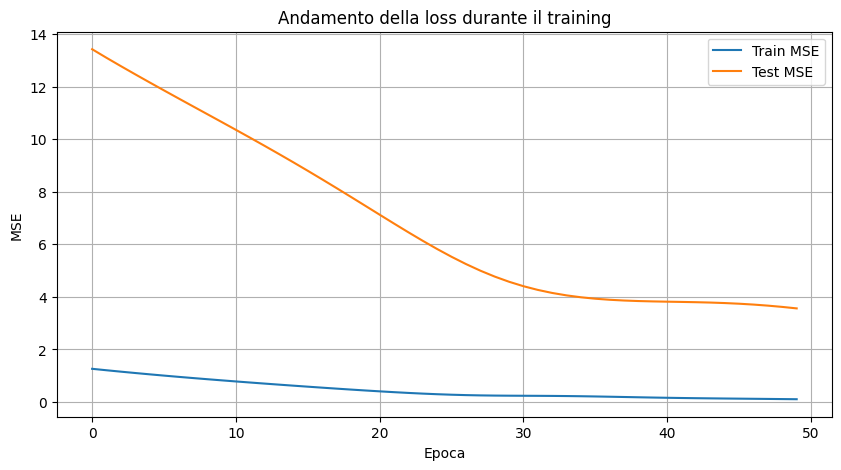

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(range(n_epochs), train_losses, label="Train MSE")
plt.plot(range(n_epochs), test_losses, label="Test MSE")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.title("Andamento della loss durante il training")
plt.legend()
plt.grid(True)
plt.show()

Okay, but it's better to add a validation step to choose the right number of epochs and be more rigorous.

New chronological in three parts: 70% train / 15% validation / 15% test

### Validation Step for Epoch Selection (Corrected)

To be more rigorous, it's better to add a validation step to choose the optimal number of epochs.

New chronological split in three parts: 70% train / 15% validation / 15% test.

In [ ]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]


mean = train_df.mean()
std = train_df.std()
train_s = (train_df - mean) / std
val_s = (val_df - mean) / std
test_s = (test_df - mean) / std


X_train = []
y_train = []
train_values = train_s.values

for i in range(len(train_values) - seq_len):
    X_train.append(train_values[i : i + seq_len, :])
    y_train.append(train_values[i + seq_len, 1])  # FTSE_MIB

X_train = np.array(X_train)
y_train = np.array(y_train)

# new validation windows
X_val = []
y_val = []
val_values = val_s.values

for i in range(len(val_values) - seq_len):
    X_val.append(val_values[i : i + seq_len, :])
    y_val.append(val_values[i + seq_len, 1])  # FTSE_MIB

X_val = np.array(X_val)
y_val = np.array(y_val)


X_test = []
y_test = []
test_values = test_s.values

for i in range(len(test_values) - seq_len):
    X_test.append(test_values[i : i + seq_len, :])
    y_test.append(test_values[i + seq_len, 1])  # FTSE_MIB

X_test = np.array(X_test)
y_test = np.array(y_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [ ]:

torch.manual_seed(42)
model = FtseRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

max_epochs = 1500   # max epochs
patience = 15       # number of maximum epochs without an improvement
min_delta = 1e-4

best_val_loss = float("inf")
best_epoch = 0
epochs_no_improve = 0
best_state = None

train_losses = []
val_losses = []

for epoch in range(max_epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # validation MSE on training data
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_t)
        val_loss = criterion(y_pred_val, y_val_t)
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss - min_delta:
        best_val_loss = val_loss.item()
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(epoch, loss.item(), val_loss.item())

    if epochs_no_improve >= patience:
        print(f"Early stopping, epoch {epoch} (no improvements for {patience} epochs)")
        break

print(f"Best Epoch: {best_epoch}, validation MSE: {best_val_loss:.6f}")

model.load_state_dict(best_state)

0 1.2610074281692505 4.778502464294434
10 0.7980173230171204 3.540193557739258
20 0.4396935999393463 2.11303448677063
30 0.24524109065532684 0.9219958782196045
40 0.15619836747646332 0.6969770789146423
50 0.08865172415971756 0.6424464583396912
60 0.05207783356308937 0.4341602623462677
70 0.041350316256284714 0.39700475335121155
80 0.03409567102789879 0.30995622277259827
90 0.030367041006684303 0.28453993797302246
100 0.027589842677116394 0.2504675090312958
110 0.02578694559633732 0.2326207160949707
120 0.02463848702609539 0.21235723793506622
130 0.023888640105724335 0.2004268318414688
140 0.023411476984620094 0.18960900604724884
150 0.02307327836751938 0.18267102539539337
160 0.02279716171324253 0.17752942442893982
170 0.022546885535120964 0.1731978803873062
180 0.022311044856905937 0.1694529503583908
190 0.022085949778556824 0.16571825742721558
200 0.021870320662856102 0.16200973093509674
210 0.021663237363100052 0.15837468206882477
220 0.02146397903561592 0.15478762984275818
230 0.02

<All keys matched successfully>

Test MSE finale: 1.003404974937439


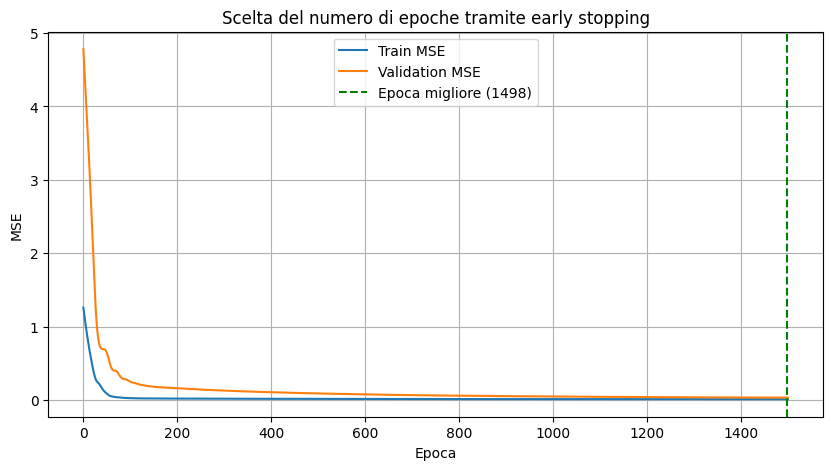

In [ ]:
# Validation MSE on test set
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t)
    test_loss = criterion(y_pred_test, y_test_t)

print("Test MSE finale:", test_loss.item())

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Validation MSE")
plt.axvline(best_epoch, color="green", linestyle="--", label=f"Epoca migliore ({best_epoch})")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.title("Scelta del numero di epoche tramite early stopping")
plt.legend()
plt.grid(True)
plt.show()

We add a benchmark to evaluate our RNNs: MSE of a random walk (MSE = 0.007)

### RNN Benchmark with Random Walk (Corrected)

We add a benchmark to evaluate our RNNs: the Mean Squared Error (MSE) of a random walk.

In [ ]:
# baseline naive: random walk
y_pred_naive_test = X_test_t[:, -1, 1]
naive_mse = criterion(y_pred_naive_test, y_test_t)
print("Test MSE baseline naive (random walk):", naive_mse.item())

Test MSE baseline naive (random walk): 0.007447060197591782


Both RNNs have a worst MSE compared to random walk.

### RNN vs. Random Walk MSE Comparison (Corrected)

Both RNNs have a worse MSE compared to the random walk.

### RNN using log-returns

Since the FTSE MIB log-price appears to behave approximately as a non-stationary process, we additionally estimate a recurrent neural network using log-returns instead of log-prices. Log-returns are obtained as the first differences of log-prices and are more suitable for modelling stationary financial time series. This specification allows us to investigate whether the RNN can identify short-term nonlinear patterns in returns and whether these patterns provide predictive information beyond the persistence captured by the random-walk benchmark.

The model is trained using a chronological train-validation-test split. The standardization parameters are estimated exclusively on the training set and then applied unchanged to the validation and test sets. The validation set is used to select the optimal number of epochs through early stopping, while the test set is kept completely separate and is used only for the final out-of-sample evaluation.


### RNN using Log-Returns (Corrected)

Since the FTSE MIB log-price appears to behave approximately as a non-stationary process, we additionally estimate a recurrent neural network using log-returns instead of log-prices. Log-returns are obtained as the first differences of log-prices and are more suitable for modeling stationary financial time series. This specification allows us to investigate whether the RNN can identify short-term nonlinear patterns in returns and whether these patterns provide predictive information beyond the persistence captured by the random-walk benchmark.

The model is trained using a chronological train-validation-test split. The standardization parameters are estimated exclusively on the training set and then applied unchanged to the validation and test sets. The validation set is used to select the optimal number of epochs through early stopping, while the test set is kept completely separate and is used only for the final out-of-sample evaluation.

Early stopping at epoch 25
Best epoch: 10
Best validation MSE: 0.393204
Final Test MSE - RNN on log-returns: 0.532573
Test MSE - Naive return benchmark: 0.994082


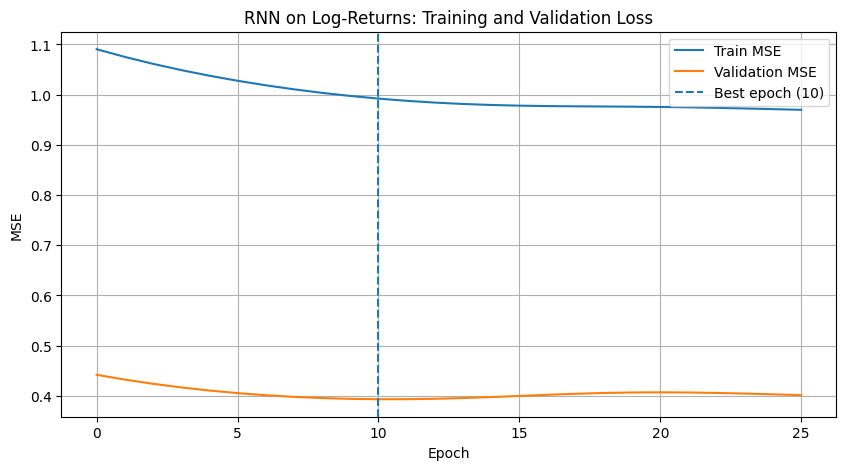

In [ ]:
# Log-returns dataset
returns_df = log_returns.dropna()[["Oil", "FTSE_MIB", "SP500"]]

# Chronological split: 70% train, 15% validation, 15% test
n = len(returns_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_ret = returns_df.iloc[:train_end]
val_ret = returns_df.iloc[train_end:val_end]
test_ret = returns_df.iloc[val_end:]

# Standardization using TRAINING statistics only
mean_ret = train_ret.mean()
std_ret = train_ret.std()

train_s = (train_ret - mean_ret) / std_ret
val_s = (val_ret - mean_ret) / std_ret
test_s = (test_ret - mean_ret) / std_ret

# Create rolling windows
seq_len = 20

def create_sequences(data, seq_len):
    X, y = [], []
    values = data.values

    for i in range(len(values) - seq_len):
        X.append(values[i:i + seq_len, :])
        y.append(values[i + seq_len, 1])  # FTSE MIB log-return

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_s, seq_len)
X_val, y_val = create_sequences(val_s, seq_len)
X_test, y_test = create_sequences(test_s, seq_len)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Initialize RNN
torch.manual_seed(42)

model_ret = FtseRNN()
criterion_ret = nn.MSELoss()
optimizer_ret = torch.optim.Adam(model_ret.parameters(), lr=0.001)

# Early stopping parameters
max_epochs = 1500
patience = 15
min_delta = 1e-4

best_val_loss = float("inf")
best_epoch = 0
epochs_no_improve = 0
best_state = None

train_losses = []
val_losses = []

# Training
for epoch in range(max_epochs):

    model_ret.train()
    optimizer_ret.zero_grad()

    y_pred = model_ret(X_train_t)
    train_loss = criterion_ret(y_pred, y_train_t)

    train_loss.backward()
    optimizer_ret.step()

    train_losses.append(train_loss.item())

    # Validation
    model_ret.eval()

    with torch.no_grad():
        y_pred_val = model_ret(X_val_t)
        val_loss = criterion_ret(y_pred_val, y_val_t)

    val_losses.append(val_loss.item())

    # Save the best model
    if val_loss.item() < best_val_loss - min_delta:

        best_val_loss = val_loss.item()
        best_epoch = epoch
        epochs_no_improve = 0

        best_state = {
            k: v.clone()
            for k, v in model_ret.state_dict().items()
        }

    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best model
model_ret.load_state_dict(best_state)

print(f"Best epoch: {best_epoch}")
print(f"Best validation MSE: {best_val_loss:.6f}")

# Final evaluation on the TEST set
model_ret.eval()

with torch.no_grad():
    y_pred_test = model_ret(X_test_t)
    test_mse = criterion_ret(y_pred_test, y_test_t)

print(f"Final Test MSE - RNN on log-returns: {test_mse.item():.6f}")

# Naive benchmark: tomorrow's return equals today's return
y_pred_naive = X_test_t[:, -1, 1]

naive_mse = criterion_ret(
    y_pred_naive,
    y_test_t
)

print(f"Test MSE - Naive return benchmark: {naive_mse.item():.6f}")

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Validation MSE")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("RNN on Log-Returns: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

We obtained Final Test MSE - RNN on log-returns: 0.532573 while
Test MSE - Naive return benchmark: 0.994082. So using log-returns our RNN is better tha Naive return benchmark where the prevision is equal to the t-1 value so Y_t_estimated = Y_t-1.


### RNN Performance vs. Naive Benchmark (Corrected)

We obtained a Final Test MSE for the RNN on log-returns of 0.532573, while the Test MSE for the Naive return benchmark was 0.994082. Thus, when using log-returns, our RNN outperforms the Naive return benchmark, where the prediction is simply equal to the previous period's value (Y_t_estimated = Y_t-1).

Now we can compare these results using a VAR on log returns.

### VAR Model Comparison (Corrected)

Now we can compare these results using a VAR model on log-returns.

In [ ]:
train_var_df = pd.concat([train_s, val_s])

var_model_setup = VAR(train_var_df)
lag_selection = var_model_setup.select_order(maxlags=15)
print("---  LAG SELECTION FOR VAR ---")
print(lag_selection.summary())

---  LAG SELECTION FOR VAR ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -0.7025     -0.6947      0.4954     -0.6996
1      -0.7668     -0.7356      0.4645     -0.7554
2      -0.8030     -0.7484      0.4480     -0.7830
3      -0.8298    -0.7519*      0.4361     -0.8014
4      -0.8411     -0.7398      0.4312     -0.8040
5      -0.8397     -0.7150      0.4318     -0.7941
6      -0.8655     -0.7174      0.4209     -0.8114
7      -0.8940     -0.7225      0.4090    -0.8313*
8      -0.8978     -0.7029      0.4075     -0.8265
9      -0.9092     -0.6910      0.4028     -0.8294
10     -0.9144     -0.6728      0.4008     -0.8261
11     -0.9117     -0.6467      0.4018     -0.8148
12    -0.9148*     -0.6265     0.4006*     -0.8095
13     -0.9121     -0.6004      0.4017     -0.7982
14     -0.9077     -0.5726      0.4034     -0.7852
15     -0.9110     -0.5525      0.4021     -0.7800


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:

# Choosing LAG based on BIC criteria
optimal_lags = lag_selection.bic
if optimal_lags == 0:
    optimal_lags = 1
print(f"\nLag scelti (secondo criterio BIC): {optimal_lags}")



Lag scelti (secondo criterio BIC): 3


In [ ]:

var_model = VAR(train_var_df)
var_results = var_model.fit(optimal_lags)


full_series = pd.concat([train_var_df, test_s])

var_preds = []
actual_targets = []


test_start_idx = len(train_var_df) + seq_len

for i in range(test_start_idx, len(full_series)):
    forecast_input = full_series.iloc[i - optimal_lags:i].values

    pred = var_results.forecast(y=forecast_input, steps=1)

    var_preds.append(pred[0, 1])
    actual_targets.append(full_series.iloc[i, 1])

var_preds = np.array(var_preds)
actual_targets = np.array(actual_targets)

var_mse = np.mean((var_preds - actual_targets) ** 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



 FINAL MODEL COMPARISON (MSE on Standardized Log-Returns)
1. Naive Benchmark (Random Walk): 0.994082
2. VAR(p=3) on Log-Returns:      0.490353
3. RNN (LSTM/RNN) on Log-Returns: 0.532573


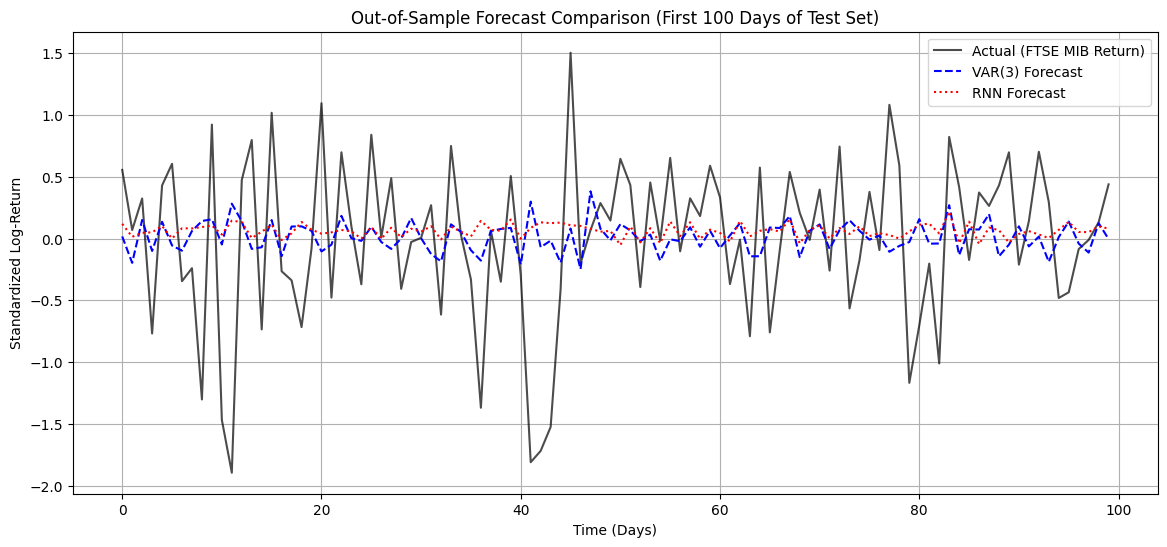

In [ ]:
print("\n==========================================================")
print(" FINAL MODEL COMPARISON (MSE on Standardized Log-Returns)")
print("==========================================================")
print(f"1. Naive Benchmark (Random Walk): {naive_mse.item():.6f}")
print(f"2. VAR(p={optimal_lags}) on Log-Returns:      {var_mse:.6f}")
print(f"3. RNN (LSTM/RNN) on Log-Returns: {test_mse.item():.6f}")
print("==========================================================")

# Plot Forecasts for the first 100 days of the Test Set
plt.figure(figsize=(14, 6))
plt.plot(actual_targets[:100], label="Actual (FTSE MIB Return)", color="black", alpha=0.7)
plt.plot(var_preds[:100], label=f"VAR({optimal_lags}) Forecast", color="blue", linestyle="--")
plt.plot(y_pred_test.numpy()[:100], label="RNN Forecast", color="red", linestyle=":")
plt.title("Out-of-Sample Forecast Comparison (First 100 Days of Test Set)")
plt.xlabel("Time (Days)")
plt.ylabel("Standardized Log-Return")
plt.legend()
plt.grid(True)
plt.show()

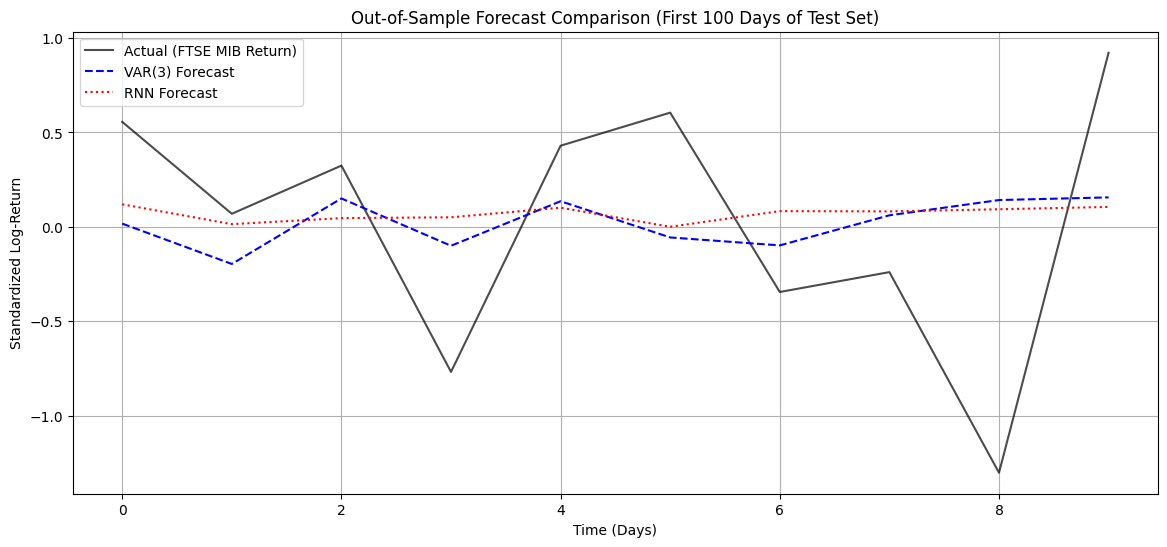

In [ ]:

# FOCUS
plt.figure(figsize=(14, 6))
plt.plot(actual_targets[:10], label="Actual (FTSE MIB Return)", color="black", alpha=0.7)
plt.plot(var_preds[:10], label=f"VAR({optimal_lags}) Forecast", color="blue", linestyle="--")
plt.plot(y_pred_test.numpy()[:10], label="RNN Forecast", color="red", linestyle=":")
plt.title("Out-of-Sample Forecast Comparison (First 100 Days of Test Set)")
plt.xlabel("Time (Days)")
plt.ylabel("Standardized Log-Return")
plt.legend()
plt.grid(True)
plt.show()

**Introduction: From Vanilla RNN to LSTM**

A Vanilla Recurrent Neural Network (RNN), as what we used above, updates its state using a simple transformation. While this works for short sequences, it struggles with longer time series because gradients vanish or explode during training.

A Long Short-Term Memory (LSTM) network fixes this problem by adding a cell state (a long-term memory line) controlled by three gates:

- Forget Gate: Decides what past information to throw away.

- Input Gate: Decides what new information to store.

- Output Gate: Decides what information to output as the prediction.

**Why Log-Returns Matter**
Stock prices behave like Random Walks and are non-stationary. To make the data stationary, we transform prices into log-returns. Since daily returns are noisy and have short memory, the LSTM's forget gate helps filter out irrelevant past noise, allowing the network to focus on brief, useful patterns across market assets.

In [ ]:
class FtseLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, num_layers=1):
        """
        PyTorch LSTM module for multi-variable time series forecasting.

        Parameters:
        - input_size: Number of input features (3: Oil, FTSE_MIB, SP500)
        - hidden_size: Number of features in the hidden state (hyperparameter)
        - num_layers: Number of stacked LSTM layers
        """
        super().__init__()
        # Replace vanilla nn.RNN with nn.LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        # Linear layer mapping the last hidden state output to a single forecast
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # 'out' contains output features from the last layer of the LSTM for each t
        # '(h_n, c_n)' contains the final hidden state and cell state
        out, (h_n, c_n) = self.lstm(x)

        # Extract the hidden state corresponding to the final time step of the sequence
        last_hidden = out[:, -1, :]

        # Pass through the linear head to generate predictions
        y_hat = self.head(last_hidden)
        return y_hat.squeeze(-1)


# ==============================================================================
# 2. MODEL INITIALIZATION, LOSS FUNCTION & OPTIMIZER
# ==============================================================================

# Set random seed for reproducibility
torch.manual_seed(42)

# Instantiate the LSTM model
model_lstm = FtseLSTM(input_size=3, hidden_size=32)
criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=0.001)


# ==============================================================================
# 3. EARLY STOPPING SETUP & TRAINING LOOP
# ==============================================================================

max_epochs = 1500
patience = 15
min_delta = 1e-4

best_val_loss_lstm = float("inf")
best_epoch_lstm = 0
epochs_no_improve_lstm = 0
best_state_lstm = None

train_losses_lstm = []
val_losses_lstm = []

# Training loop
for epoch in range(max_epochs):
    # Set model to training mode
    model_lstm.train()
    optimizer_lstm.zero_grad()

    # Forward pass on training set
    y_pred = model_lstm(X_train_t)
    train_loss = criterion_lstm(y_pred, y_train_t)

    # Backward pass and optimization
    train_loss.backward()
    optimizer_lstm.step()

    train_losses_lstm.append(train_loss.item())

    # Evaluation on Validation set
    model_lstm.eval()
    with torch.no_grad():
        y_pred_val = model_lstm(X_val_t)
        val_loss = criterion_lstm(y_pred_val, y_val_t)

    val_losses_lstm.append(val_loss.item())

    # Checkpoint evaluation for Early Stopping
    if val_loss.item() < best_val_loss_lstm - min_delta:
        best_val_loss_lstm = val_loss.item()
        best_epoch_lstm = epoch
        epochs_no_improve_lstm = 0
        best_state_lstm = {k: v.clone() for k, v in model_lstm.state_dict().items()}
    else:
        epochs_no_improve_lstm += 1

    # Trigger early stopping if no improvement is observed
    if epochs_no_improve_lstm >= patience:
        print(f"Early stopping triggered for LSTM at epoch {epoch}")
        break

# Restore best model parameters from validation phase
model_lstm.load_state_dict(best_state_lstm)


# ==============================================================================
# 4. OUT-OF-SAMPLE EVALUATION ON TEST SET
# ==============================================================================

model_lstm.eval()
with torch.no_grad():
    y_pred_test_lstm = model_lstm(X_test_t)
    test_mse_lstm = criterion_lstm(y_pred_test_lstm, y_test_t)

print(f"\nBest Epoch LSTM: {best_epoch_lstm}")
print(f"Final Test MSE - LSTM on log-returns: {test_mse_lstm.item():.6f}")

Early stopping triggered for LSTM at epoch 17

Best Epoch LSTM: 2
Final Test MSE - LSTM on log-returns: 0.529362


In [ ]:
print("\n==========================================================")
print(" UPDATED MODEL COMPARISON (MSE on Standardized Log-Returns)")
print("==========================================================")
print(f"1. Naive Benchmark (Random Walk): {naive_mse.item():.6f}")
print(f"2. VAR(p={optimal_lags}) on Log-Returns:      {var_mse:.6f}")
print(f"3. Vanilla RNN on Log-Returns:     {test_mse.item():.6f}")
print(f"4. LSTM Network on Log-Returns:    {test_mse_lstm.item():.6f}")
print("==========================================================")


 UPDATED MODEL COMPARISON (MSE on Standardized Log-Returns)
1. Naive Benchmark (Random Walk): 0.994082
2. VAR(p=3) on Log-Returns:      0.490353
3. Vanilla RNN on Log-Returns:     0.532573
4. LSTM Network on Log-Returns:    0.529362


The empirical results confirm that modeling stationary log-returns significantly reduces out-of-sample forecast errors compared to the Naive Random Walk benchmark, cutting the MSE by approximately 50%. The linear VAR(3) model achieves the lowest overall MSE (0.490353), outperforming deep learning architectures. While the LSTM network (0.529362) shows a slight improvement over the Vanilla RNN (0.532573) due to its gating mechanism, the marginal gain remains small. This highlights that daily financial returns are predominantly governed by short-term linear relationships, where complex non-linear models face a higher risk of fitting high-frequency noise.

### Empirical Results and Model Performance (Corrected)

The empirical results confirm that modeling stationary log-returns significantly reduces out-of-sample forecast errors compared to the Naive Random Walk benchmark, cutting the MSE by approximately 50%. The linear VAR(3) model achieves the lowest overall MSE (0.490353), outperforming deep learning architectures. While the LSTM network (0.529362) shows a slight improvement over the Vanilla RNN (0.532573) due to its gating mechanism, the marginal gain remains small. This highlights that daily financial returns are predominantly governed by short-term linear relationships, where complex nonlinear models face a higher risk of fitting high-frequency noise.

THE WINNER IS ...... VAR model 👏👏👏 but as you can look at below, RNN models and VAR are similar in terms of predictive accuracy but VAR is less complex compare to RNNs

### Model Comparison Winner (Corrected)

THE WINNER IS ...... the VAR model 👏👏👏 However, as you can see below, RNN models and VAR models are similar in terms of predictive accuracy, but VAR is less complex compared to RNNs.

The Diebold-Mariano test compares the squared forecast errors of two models and tells you whether the difference in predictive accuracy is significant. It shows you understand that "lower MSE" alone isn't proof of a better model.

### Diebold-Mariano Test Explanation (Corrected)

The Diebold-Mariano test compares the squared forecast errors of two models and indicates whether the difference in predictive accuracy is statistically significant. It highlights that 'lower MSE' alone is not sufficient proof of a superior model.

In [ ]:
# ==============================================================================
# DIEBOLD-MARIANO TEST: is VAR significantly more accurate than the RNN?
# ==============================================================================
# H0: the two models have equal predictive accuracy (no significant difference)
# H1: one model is significantly more accurate than the other
# We use squared-error loss (consistent with MSE) and a 1-step-ahead horizon,
# so no Newey-West lag correction is needed (h=1 -> no autocorrelation in d_t
# expected under the null).

from scipy.stats import norm

rnn_preds_for_dm = y_pred_test.numpy()  # RNN forecasts, log-returns section
actual_for_dm = actual_targets          # same target array used for VAR comparison

e_var = actual_for_dm - var_preds
e_rnn = actual_for_dm - rnn_preds_for_dm

d = e_var**2 - e_rnn**2  # loss differential, per period

d_mean = d.mean()
d_var = d.var(ddof=1)
T = len(d)

dm_stat = d_mean / np.sqrt(d_var / T)
dm_pvalue = 2 * (1 - norm.cdf(abs(dm_stat)))

print("==========================================================")
print(" DIEBOLD-MARIANO TEST: VAR vs RNN (log-returns)")
print("==========================================================")
print(f"DM statistic: {dm_stat:.4f}")
print(f"p-value:      {dm_pvalue:.4f}")
if dm_pvalue < 0.05:
    print("=> The difference in forecast accuracy IS statistically significant.")
else:
    print("=> The difference in forecast accuracy is NOT statistically significant.")

 DIEBOLD-MARIANO TEST: VAR vs RNN (log-returns)
DM statistic: -1.7804
p-value:      0.0750
=> The difference in forecast accuracy is NOT statistically significant.


To be sure, we check if there is a cointegration relationship between "Oil", "FTSE_MIB", "SP500. Above we have already escluded this kind of relationship between FTSE_MIB and SP500 but it can exist a multivariate cointegration relationship

### Multivariate Cointegration Check (Corrected)

To confirm, we will check for a cointegration relationship between Oil, FTSE_MIB, and SP500. Although we previously excluded such a relationship between FTSE_MIB and SP500, a multivariate cointegration relationship might exist.

In [ ]:

df_train_3var = train_data.dropna()[["Oil", "FTSE_MIB", "SP500"]]

johansen_3var = coint_johansen(df_train_3var, det_order=1, k_ar_diff=2)

trace_df_3var = pd.DataFrame({
    'Test Statistic (Trace)': johansen_3var.lr1,
    'Crit 95%': johansen_3var.cvt[:, 1],
}, index=[f"r <= {i}" for i in range(3)])

print("==========================================================")
print("JOHANSEN TEST (TRIVARIATE: Oil, FTSE MIB, S&P 500)")
print("==========================================================")
print(trace_df_3var.round(4))

JOHANSEN TEST (TRIVARIATE: Oil, FTSE MIB, S&P 500)
        Test Statistic (Trace)  Crit 95%
r <= 0                 32.8338   35.0116
r <= 1                 18.6454   18.3985
r <= 2                  7.8747    3.8415


No cointegration

### Cointegration Result (Corrected)

No cointegration found.

**Additional attemps on RNN**

We retrain the same RNN architecture with a couple of alternative hidden_size values to check whether 32 is actually a reasonable choice, rather than an arbitrary one. Same early stopping setup as the main training loop.


### Additional Attempts with RNN (Corrected)

We retrain the same RNN architecture with a couple of alternative `hidden_size` values to check whether 32 is actually a reasonable choice, rather than an arbitrary one. The same early stopping setup as the main training loop is used.

In [ ]:

hidden_size_options = [16, 32, 64]

print("==========================================================")
print(" HIDDEN SIZE SENSITIVITY CHECK")
print("==========================================================")

for hs in hidden_size_options:
    torch.manual_seed(42)

    class FtseRNN_hs(nn.Module):
        def __init__(self, hidden_size):
            super().__init__()
            self.rnn = nn.RNN(input_size=3, hidden_size=hidden_size, batch_first=True)
            self.head = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, h_n = self.rnn(x)
            last_hidden = out[:, -1, :]
            return self.head(last_hidden).squeeze(-1)

    model_hs = FtseRNN_hs(hidden_size=hs)
    criterion_hs = nn.MSELoss()
    optimizer_hs = torch.optim.Adam(model_hs.parameters(), lr=0.001)

    best_val_loss_hs = float("inf")
    epochs_no_improve_hs = 0
    best_state_hs = None

    for epoch in range(max_epochs):
        model_hs.train()
        optimizer_hs.zero_grad()
        y_pred = model_hs(X_train_t)
        loss = criterion_hs(y_pred, y_train_t)
        loss.backward()
        optimizer_hs.step()

        model_hs.eval()
        with torch.no_grad():
            val_loss = criterion_hs(model_hs(X_val_t), y_val_t)

        if val_loss.item() < best_val_loss_hs - min_delta:
            best_val_loss_hs = val_loss.item()
            epochs_no_improve_hs = 0
            best_state_hs = {k: v.clone() for k, v in model_hs.state_dict().items()}
        else:
            epochs_no_improve_hs += 1

        if epochs_no_improve_hs >= patience:
            break

    model_hs.load_state_dict(best_state_hs)
    model_hs.eval()
    with torch.no_grad():
        test_mse_hs = criterion_hs(model_hs(X_test_t), y_test_t)

    print(f"hidden_size={hs:>3} -> Test MSE: {test_mse_hs.item():.6f}")

 HIDDEN SIZE SENSITIVITY CHECK
hidden_size= 16 -> Test MSE: 0.507543
hidden_size= 32 -> Test MSE: 0.532573
hidden_size= 64 -> Test MSE: 0.493710




The test MSE does not improve steadily as hidden_size grows: 16 -> 0.5075,
32 -> 0.5326, 64 -> 0.4937. If a bigger hidden size were really helping the
model learn more useful patterns, we would expect the MSE to go down step by
step as hidden_size increases. Instead, 32 is slightly worse than 16, and 64
is the best, but only by a small amount, similar to the small gaps we already
saw between the RNN, the LSTM, and the VAR model.

This fits with what we found earlier: since log-returns have very little
autocorrelation, giving the model more capacity does not reliably lower the
error. The differences between hidden sizes look more like the effect of
random initialization and early stopping timing, not a real gain in learning
power. hidden_size=32 is still a fine, reasonable choice - it is not clearly
wrong - but this check shows that changing this hyperparameter is not the
main issue. The real limit is that the target series itself is hard to
predict.

### Hidden Size Sensitivity Check Analysis (Corrected)

The test MSE does not improve steadily as `hidden_size` grows: 16 -> 0.5075, 32 -> 0.5326, 64 -> 0.4937. If a larger hidden size were truly helping the model learn more useful patterns, we would expect the MSE to decrease step by step as `hidden_size` increases. Instead, 32 is slightly worse than 16, and 64 is the best, but only by a small amount, similar to the small gaps we already saw between the RNN, the LSTM, and the VAR model.

This observation aligns with our earlier findings: since log-returns exhibit very little autocorrelation, providing the model with more capacity does not reliably lower the error. The differences between hidden sizes appear to be more a result of random initialization and early stopping timing, rather than a genuine gain in learning power. While `hidden_size=32` remains a fine, reasonable choice—it is not clearly wrong—this check demonstrates that altering this hyperparameter is not the main issue. The real limitation is that the target series itself is inherently difficult to predict.

**Economic Intuition: Linking Cointegration to Neural Network Performance**

The empirical results from both econometric modeling and deep learning architectures align logically around a single fundamental characteristic of our dataset: the memory structure of time series.
1. The Analogy: Vanilla RNN vs. LSTMTo understand why the two neural networks performed so similarly, consider how they process sequential information: Vanilla RNN (The Student with Short-Term Memory): A standard RNN processes data line-by-line. However, it suffers from the vanishing gradient problem, meaning its memory fades rapidly over time. It is like a student who reads a textbook but forgets what was written ten pages ago, retaining only what was read yesterday.LSTM (The Student with a Notebook): An LSTM overcomes this limitation by introducing a Cell State—a dedicated notebook—regulated by three gates:Forget Gate: Erases irrelevant past notes with an eraser.Input Gate: Highlights and writes down important new information.Output Gate: Decides which notes to use to make tomorrow's prediction.
2. The Link to Cointegration (Johansen Test)In our econometric analysis, the Johansen cointegration test was conducted specifically between the FTSE MIB and S&P 500 log-prices (excluding Crude Oil to test for a direct bivariate long-run equilibrium between the two equity indices).The test revealed no cointegration ($r = 0$). Econometrically, this implies that while both equity indices follow $I(1)$ non-stationary processes, there is no stationary linear combination binding them together over the long run (i.e., no long-term "equilibrium attractor").

**Why the LSTM Yields No Major Gain**

This absence of cointegration directly explains the neural network outcomes:
- No Long-Term Memory in Returns: Because log-prices are not cointegrated, long-term historical price levels carry no structural predictive power. The only stationary information resides in the log-returns, whose autocorrelation dies out after very few lags ($1–3$ days).
- Unused Gating Capacity: Since daily log-returns lack long-term memory, the LSTM's Forget Gate actively erases distant past information to minimize error. As a result, the LSTM's dedicated "notebook" (Cell State) remains effectively unused for long horizons.
- Convergence of Architectures: Without long-term signal to capture, the LSTM collapses into a short-term estimator, yielding an MSE (0.529362) almost identical to the Vanilla RNN (0.532573) and slightly behind the parsimonious VAR(3) model (0.490353).



Ultimately, daily financial returns are driven by short-lived signals and dominated by noise, proving that in high-frequency market forecasting, long-term memory is largely an illusion and parsimony remains the most effective defense against overfitting.

**Closing Reflection**

At the start, it was tempting to blame hidden_size, learning rate, or
num_layers for the RNN not beating the VAR model. But the sensitivity check
showed something more interesting: test MSE didn't really improve as
hidden_size went from 16 to 32 to 64 (0.5075, 0.5326, 0.4937) , so there was no
clear, steady gain from giving the model more capacity.

That result lines up with what we already found earlier in the project.
There's no cointegration between Oil, FTSE MIB, and SP500, and log-returns
barely show any autocorrelation past a couple of lags. So there just isn't
much learnable signal left for the model to find. Making the network bigger
mostly means giving it more room to fit noise, not more room to fit real
patterns.

That's really the main takeaway of the whole project: no amount of tuning
can make a model learn something that isn't there in the data. The ceiling
was set by the market, not by our architecture. And that's exactly why the
simple VAR model, fewer parameters, less risk of overfitting, ends up
being the more sensible choice here, not just the "winning" one.

### Economic Intuition: Linking Cointegration to Neural Network Performance (Corrected)

The empirical results from both econometric modeling and deep learning architectures align logically around a single fundamental characteristic of our dataset: the memory structure of time series.

**1. The Analogy: Vanilla RNN vs. LSTM**
To understand why the two neural networks performed so similarly, consider how they process sequential information:
*   **Vanilla RNN (The Student with Short-Term Memory):** A standard RNN processes data line-by-line. However, it suffers from the vanishing gradient problem, meaning its memory fades rapidly over time. It is like a student who reads a textbook but forgets what was written ten pages ago, retaining only what was read yesterday.
*   **LSTM (The Student with a Notebook):** An LSTM overcomes this limitation by introducing a Cell State—a dedicated notebook—regulated by three gates:
    *   **Forget Gate:** Erases irrelevant past notes with an eraser.
    *   **Input Gate:** Highlights and writes down important new information.
    *   **Output Gate:** Decides which notes to use to make tomorrow's prediction.

**2. The Link to Cointegration (Johansen Test)**
In our econometric analysis, the Johansen cointegration test was conducted specifically between the FTSE MIB and S&P 500 log-prices (excluding Crude Oil to test for a direct bivariate long-run equilibrium between the two equity indices). The test revealed no cointegration ($r = 0$). Econometrically, this implies that while both equity indices follow $I(1)$ non-stationary processes, there is no stationary linear combination binding them together over the long run (i.e., no long-term "equilibrium attractor").

**Why the LSTM Yields No Major Gain**

This absence of cointegration directly explains the neural network outcomes:
*   **No Long-Term Memory in Returns:** Because log-prices are not cointegrated, long-term historical price levels carry no structural predictive power. The only stationary information resides in the log-returns, whose autocorrelation dies out after very few lags ($1–3$ days).
*   **Unused Gating Capacity:** Since daily log-returns lack long-term memory, the LSTM's Forget Gate actively erases distant past information to minimize error. As a result, the LSTM's dedicated "notebook" (Cell State) remains effectively unused for long horizons.
*   **Convergence of Architectures:** Without a long-term signal to capture, the LSTM collapses into a short-term estimator, yielding an MSE (0.529362) almost identical to the Vanilla RNN (0.532573) and slightly behind the parsimonious VAR(3) model (0.490353).

Ultimately, daily financial returns are driven by short-lived signals and dominated by noise, proving that in high-frequency market forecasting, long-term memory is largely an illusion and parsimony remains the most effective defense against overfitting.

**Closing Reflection**

At the start, it was tempting to blame `hidden_size`, learning rate, or `num_layers` for the RNN not beating the VAR model. But the sensitivity check showed something more interesting: test MSE didn't really improve as `hidden_size` went from 16 to 32 to 64 (0.5075, 0.5326, 0.4937), so there was no clear, steady gain from giving the model more capacity.

That result lines up with what we already found earlier in the project. There's no cointegration between Oil, FTSE MIB, and SP500, and log-returns barely show any autocorrelation past a couple of lags. So there just isn't much learnable signal left for the model to find. Making the network bigger mostly means giving it more room to fit noise, not more room to fit real patterns.

That's really the main takeaway of the whole project: no amount of tuning can make a model learn something that isn't there in the data. The ceiling was set by the market, not by our architecture. And that's exactly why the simple VAR model, with fewer parameters and less risk of overfitting, ends up being the more sensible choice here, not just the "winning" one.